In [88]:
## same egg identifier

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math, scipy, skimage, os, time
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['font.family'] = 'Calibri'
mpl.rcParams['font.size'] = 12
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['pdf.fonttype'] = 42

In [89]:
data_collection = pd.read_excel('B:\\home\\Xin home drive\\data_meroblastic\\majority_data_info.xlsx', sheet_name = 'lcii')
data_collection = data_collection.loc[data_collection.experiment == "xin250401_lcii_wt"]
# data_collection = data_collection.loc[data_collection.processed == 'processed']
data_collection = data_collection[['rep', 'experiment', 'batch', 'pos_x', 'pos_y']]
data_collection.pos_x += (data_collection.batch-1)*10000
# data_collection.pos_y += (data_collection.batch-1)*10000
data_collection.head()

,rep,experiment,batch,pos_x,pos_y
107,107,xin250401_lcii_wt,1.0,899.2,-2338.2
108,108,xin250401_lcii_wt,1.0,1816.7,-1465.7
109,109,xin250401_lcii_wt,1.0,-1157.5,-1146.8
110,110,xin250401_lcii_wt,1.0,78.3,-679.3
111,111,xin250401_lcii_wt,1.0,745.1,-182.1


C:\Users\xtong\AppData\Local\Temp\ipykernel_2564\3915014883.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=12)


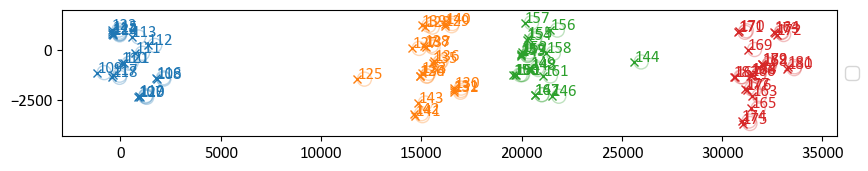

In [90]:
embryo_diameter = 700

tab10 = plt.get_cmap('tab10')
tab10_colors = list(tab10.colors) * 5

fig, ax = plt.subplots(figsize=[10, 10])

for i in data_collection.index:
    rep = data_collection.loc[i]

    ax.plot(rep.pos_x, rep.pos_y, 'x', color=tab10_colors[int(rep.batch -1)])
    ax.text(x = rep.pos_x, y = rep.pos_y, s = rep.rep, color=tab10_colors[int(rep.batch -1)])

    circle = mpl.patches.Circle(xy=(rep.pos_x + embryo_diameter/2, rep.pos_y), radius=embryo_diameter/2, fill=False, ec=tab10_colors[int(rep.batch -1)], alpha=0.3)
    ax.add_patch(circle)

ax.set_aspect(1)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=12)
plt.show()

In [91]:
from scipy.cluster.hierarchy import ward, fcluster
from scipy.spatial.distance import pdist

Z = ward(pdist(data_collection[['pos_x', 'pos_y']].values))
embryo_no_new = fcluster(Z, t=embryo_diameter*2/3, criterion='distance')

data_collection['embryo_no_new'] = embryo_no_new
display(data_collection[['rep', 'embryo_no_new']])

[print(i) for i in data_collection['embryo_no_new']]
# display(data_collection['embryo_no_new'])
print(' ')

,rep,embryo_no_new
107,107,2
108,108,1
109,109,5
110,110,3
111,111,7
...,...,...
180,180,12
181,181,12
182,182,16
183,183,18


2
1
5
3
7
8
9
6
6
1
4
4
2
2
3
6
6
6
41
40
38
36
35
32
32
32
40
40
39
39
37
37
36
35
33
33
34
31
27
26
25
29
29
28
28
27
27
21
21
23
22
24
27
28
30
25
20
13
15
17
18
16
11
10
10
13
13
14
14
19
19
17
16
12
12
16
18
17
 


C:\Users\xtong\AppData\Local\Temp\ipykernel_2564\2015265408.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=12)


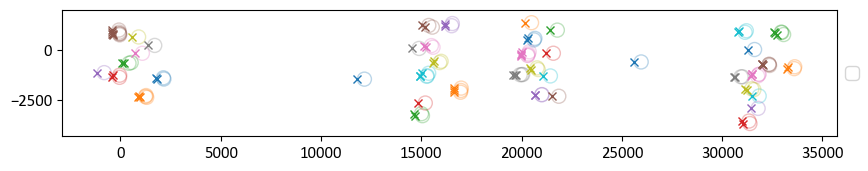

In [92]:
fig, ax = plt.subplots(figsize=[10, 10])

for i in data_collection.index:
    rep = data_collection.loc[i]

    color_rep = tab10_colors[int(rep.embryo_no_new -1)]

    ax.plot(rep.pos_x, rep.pos_y, 'x', color=color_rep)
    # ax.text(x = rep.pos_x, y = rep.pos_y, s = rep.rep, color=color_rep)

    circle = mpl.patches.Circle(xy=(rep.pos_x + embryo_diameter/2, rep.pos_y), radius=embryo_diameter/2,
                                fill=False, ec=color_rep, alpha=0.3)
    ax.add_patch(circle)

ax.set_aspect(1)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=12)
plt.show()